In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('/content/customer_churn.csv')

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
df.shape

(222464, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222464 entries, 0 to 222463
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         222463 non-null  float64
 1   Age                222463 non-null  float64
 2   Gender             222463 non-null  object 
 3   Tenure             222463 non-null  float64
 4   Usage Frequency    222463 non-null  float64
 5   Support Calls      222463 non-null  float64
 6   Payment Delay      222462 non-null  float64
 7   Subscription Type  222462 non-null  object 
 8   Contract Length    222462 non-null  object 
 9   Total Spend        222462 non-null  float64
 10  Last Interaction   222462 non-null  float64
 11  Churn              222462 non-null  float64
dtypes: float64(9), object(3)
memory usage: 20.4+ MB


In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,222463.000000,222463.000000,222463.000000,222463.000000,222463.000000,222462.000000,222462.000000,222462.000000,222462.000000
mean,114208.318192,41.647843,30.486400,15.483685,5.086787,15.136927,544.742850,15.555322,0.983665
std,66114.053130,13.931959,17.339536,8.674511,3.151162,8.964071,259.664855,8.656035,0.126762
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,56648.500000,30.000000,15.000000,8.000000,2.000000,7.000000,320.000000,8.000000,1.000000
50%,114685.000000,42.000000,30.000000,15.000000,5.000000,15.000000,540.000000,16.000000,1.000000
75%,171657.500000,54.000000,46.000000,23.000000,8.000000,23.000000,770.000000,23.000000,1.000000
max,228254.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
1.0,218828
0.0,3634


In [ ]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,2
Subscription Type,2
Contract Length,2
Total Spend,2


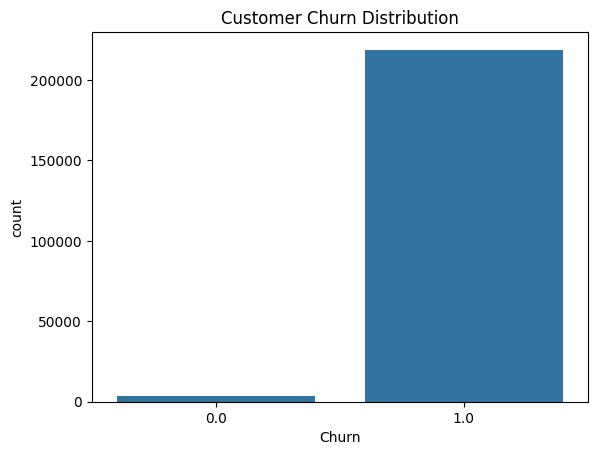

In [ ]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

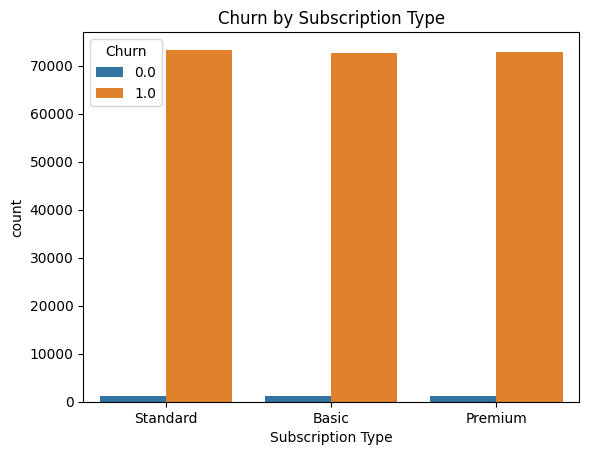

In [ ]:
sns.countplot(x='Subscription Type', hue='Churn', data=df)

plt.title('Churn by Subscription Type')
plt.show()

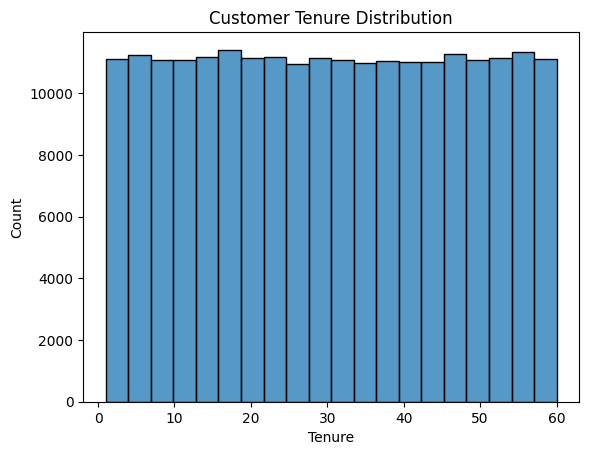

In [ ]:
sns.histplot(df['Tenure'], bins=20)

plt.title('Customer Tenure Distribution')
plt.show()

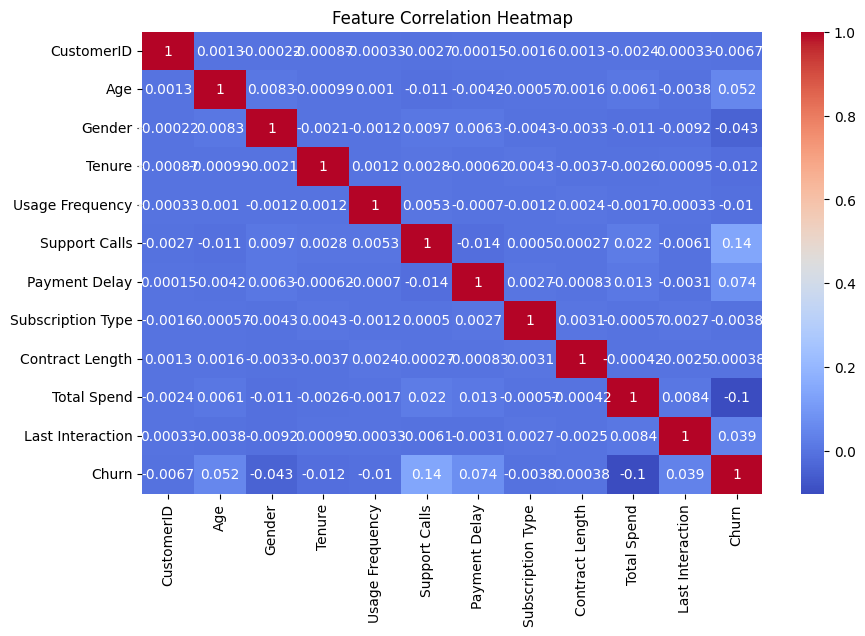

In [ ]:
temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = le.fit_transform(temp_df[col])

plt.figure(figsize=(10,6))

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
df.drop('CustomerID', axis=1, inplace=True)

In [ ]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
df.isnull().sum()

,0
Age,1
Gender,0
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,2
Subscription Type,0
Contract Length,0
Total Spend,2
Last Interaction,2


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_19159/10066818.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [ ]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9839525318589442


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[   17,   692],
       [   22, 43762]])

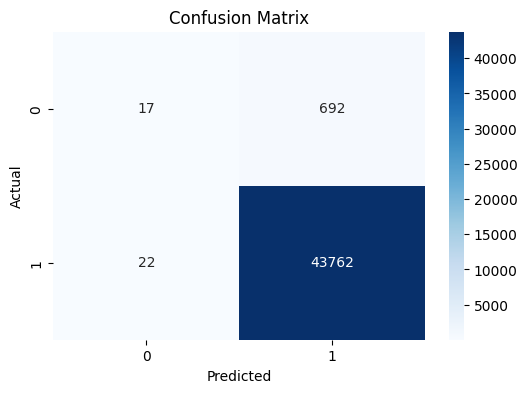

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()